### This Assignment aims to analyse product review dataset using Python and Machine Learning

Tasks Overview: 
1. Data Preparation and Characterisation
a) Load and parse the data from both input files. Integrate the two data sources
by merging them appropriately to create a single dataset. Save the new dataset
in an appropriate file format.
b) Apply any preprocessing steps required to transform the dataset's features into
suitable representations for analysis.
c) Provide a characterisation of the merged dataset, including summary statistics
and distributions for the descriptive features.
2. Review Sentiment Classification
a) Derive a binary sentiment target label (“positive” or “negative”) for each review
based on its star rating. Create a plot showing the resulting class distribution
for the dataset.
b) Prepare the text data for classification by applying appropriate preprocessing
steps to create a numeric representation suitable for machine learning. Then
build two different binary classification models using classifiers of your choice to
distinguish between "positive" and "negative" reviews.
c) Evaluate and compare the performance of your two sentiment classification
models using an appropriate evaluation strategy. Report your results using
suitable metrics and discuss the performance of the models.
3. Review Helpfulness Classification
a) Derive a binary helpfulness target label ("helpful" or "unhelpful") for each
review based on its associated helpfulness information. Create a plot showing
the resulting class distribution for the dataset.
b) Build two different binary classification models using classifiers of your choice to
distinguish between "helpful" and "unhelpful" reviews.
c) Evaluate and compare the performance of your two helpfulness classification
models using an appropriate evaluation strategy. Report your results using
suitable metrics and discuss the performance of the models. Additionally,
compare the overall performance between the sentiment classification task and
the helpfulness classification task, discussing any differences you observe.

## Task 1a:
Goal: the initial target of this section is to load both the review datasets and read them using DataFrames. Once the df are created I'm gonna merge them in a single df using primary key (i.e. 'review_id' in this case). Later that i will perform data preprocessing to clean the messy data to eliminate NAs and dublicates or any row with missing data, later I will convert the rating (*) in numeric values out of 5 to peform operation.

### Data Loading and Merger

In [87]:
import pandas as pd
import numpy as np
import json
import matplotlib.pyplot as plt 
import seaborn as sns
import re

# Loading datasets 

with open('review-text.json', 'r') as t: 
    text_data = json.load(t) 
    
with open('review-scores.json', 'r') as s: 
    score_data = json.load(s)
    
# Creating DataFrames to store our datasets in tabular format

df_text = pd.DataFrame(text_data)
df_scores = pd.DataFrame(score_data)

# Exploring Data 

print(df_text.shape)
print(df_scores.shape)

print(df_text.head())
print(df_scores.head())

# Now i will merge these two dataframes in one single dataframe using primary key, i.e review_id 
# (a primary key is that is common in both the datasets)

df_review = pd.merge(df_text, df_scores, on = 'review_id' )

print(df_review.shape)
print(df_review.head())

# Saving as CSV file

df_review.to_csv('merged_reviews.csv', index = False)

# Checking if our data merged succesfully 
print(f"Dataset merged. Total rows & columns: {df_review.shape}")

(15375, 6)
(15375, 4)
  review_id  product_id         user_id  \
0   R274002  B001O1Q0NA   AY6QZ7AY3AK8Z   
1   R302264  B000MOEUMS  A33DXT3AD5DHCB   
2    R84546  B002ZOIKMY  A14396UCW3Z0KI   
3   R117515  B0016B7Z32  A1ODU9IV6O87IB   
4   R131840  B001XUO8AY  A3LOCNXB7Z1WCH   

                             review_title  \
0                        Fluoridated salt   
1                       NOT as Advertised   
2  Best bags for iced tea, excellent deal   
3      Don't pay for "expedited" delivery   
4                      I love Fever-Tree!   

                                         review_body  review_date  
0  I thought this salt was fluoride free unfortun...   2021/01/01  
1  This product is NOT drinking chocolate.<br /><...   01-01-2021  
2  First, Luzianne makes the best classic brewed ...   2021-01-01  
3  I paid over $13.00 for "expedited" delivery an...   01-01-2021  
4  After doing an Internet search for tonic water...  01 Jan 2021  
  review_id rating  helpful_votes  total

### Handling the null values
There are some missing values in review title and review body, as these are the text values,
the missing values cannot be replaced by just any text as we do with numerical varlues replacing with mean 
values, Therefore, the best value to handle these missing values is to remove these rows. 

In [88]:
# Checking for the null values
df_review.isnull().sum()

# # Removing Null values
df_review = df_review.dropna(subset = ['review_body', 'review_title'])

# #Checking for comparison
print("After:",df_review.shape)

After: (15330, 9)


### Task 1b.a :
Applying preprocessing steps required to transform the dataset's features into
suitable representations for analysis.

In [89]:
#converting astrisk to numerical rating
df_review['rating_num'] = df_review['rating'].apply(lambda x: len(str(x)))

#checking it
df_review[['rating', 'rating_num']].head()

,rating,rating_num
0,*,1
1,***,3
2,*****,5
3,**,2
4,*****,5


### Task 1b.b: 
Now I'm gonna clean the text which is in review_body, so that the model can learn meaningful pattern.

In [90]:
def clean_text(text):
    if pd.isnull(text):   # 👈 handle null safely
        return ""
    
    text = text.lower()
    text = re.sub(r'<.*?>', ' ', text)
    text = re.sub(r'[^a-z\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    
    return text

df_review['clean_review'] = df_review['review_body'].apply(clean_text)

df_review[['review_body', 'clean_review']].head()

# Now we have clean_review which is going to be our main input to feed our Model

,review_body,clean_review
0,I thought this salt was fluoride free unfortun...,i thought this salt was fluoride free unfortun...
1,This product is NOT drinking chocolate.<br /><...,this product is not drinking chocolate i reali...
2,"First, Luzianne makes the best classic brewed ...",first luzianne makes the best classic brewed i...
3,"I paid over $13.00 for ""expedited"" delivery an...",i paid over for expedited delivery and the pro...
4,After doing an Internet search for tonic water...,after doing an internet search for tonic water...


### Task 1c:

### Summary statistics

--- Summary Statistics ---
         rating_num  helpful_votes   total_votes
count  15330.000000   15330.000000  15330.000000
mean       3.415134      21.936725     27.134573
std        1.746885      36.343259     37.229639
min        1.000000       0.000000     12.000000
25%        1.000000      10.000000     14.000000
50%        4.000000      14.000000     18.000000
75%        5.000000      22.000000     26.000000
max        5.000000     866.000000    923.000000


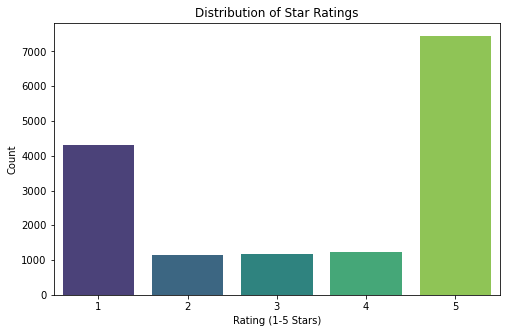

In [91]:
print("--- Summary Statistics ---")
print(df_review[['rating_num', 'helpful_votes', 'total_votes']].describe())

# Visualising the Rating Distribution
plt.figure(figsize=(8, 5))
sns.countplot(data=df_review, x='rating_num', palette='viridis')
plt.title('Distribution of Star Ratings')
plt.xlabel('Rating (1-5 Stars)')
plt.ylabel('Count')
plt.show()

Correlation Matrix:
               rating_num  helpful_votes  total_votes
rating_num       1.000000       0.147774     0.051811
helpful_votes    0.147774       1.000000     0.976679
total_votes      0.051811       0.976679     1.000000


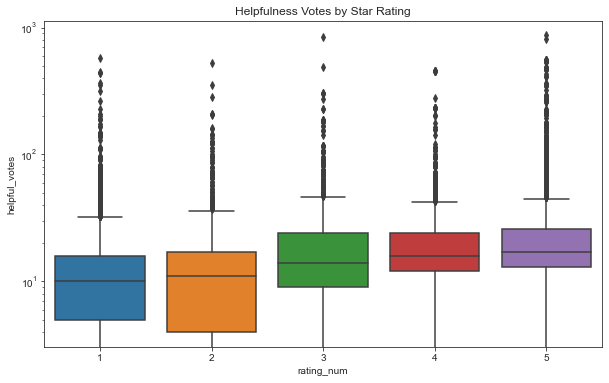

In [96]:
# Checking for Correlation between Rating and Helpfulness
correlation = df_review[['rating_num','helpful_votes', 'total_votes']].corr()
print("Correlation Matrix:")
print(correlation)

# Plotting helpfulness vs Rating

plt.figure(figsize=(10, 6))

sns.boxplot(data=df_review, x='rating_num', y='helpful_votes')

plt.title('Helpfulness Votes by Star Rating')

plt.yscale('log') # Using log scale to eliminate extreme values that could distort the chart

plt.show()

## Task 2a:
### Creating Sentiment Label
Here I'm gonna create a segmentation of ratings to categories them as sentiment. I will eliminate all the ratings with "3" stars as there are neutral for rating out of 5. I'm gonna consider rating 1 & 2 as "Negative" and rating 4 & 5 as "Positive".

In [98]:
# Removing neutral ratings i.e. "3" and creating an independent copy
df_review = df_review[df_review['rating_num'] !=3].copy()

#Creating sentiment column
df_review['sentiment'] = df_review['rating_num'].apply(lambda x: 'positive' if x >= 4 else 'negative')
    
# Checking distribution
df_review['sentiment'].value_counts()

positive    8688
negative    5458
Name: sentiment, dtype: int64

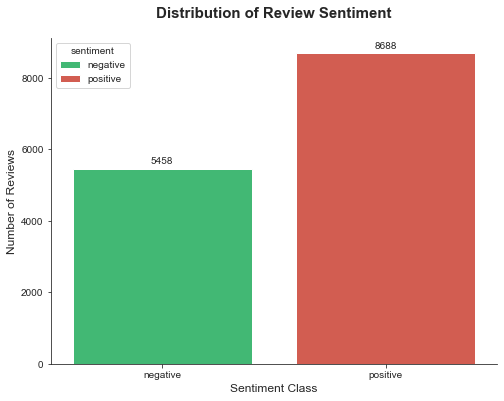

In [102]:
# Visualising Sentiment Distribution
plt.figure(figsize=(8, 6))

ax = sns.countplot(data=df_review, x='sentiment', hue='sentiment', 
                   palette=['#2ecc71', '#e74c3c'], dodge=False)

ax.bar_label(ax.containers[0], padding=3)
ax.bar_label(ax.containers[1], padding=3)

plt.title('Distribution of Review Sentiment', fontsize=15, fontweight='bold', pad=20)
plt.xlabel('Sentiment Class', fontsize=12)
plt.ylabel('Number of Reviews', fontsize=12)

sns.despine()
plt.show()

### Task 2b:
Computer can't calculate sentiment directly from the text, thus In this task we would be turning the text into numbers using Vectorisation.

In [104]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

# Setting features and targets
f1 = df_review['review_body']
f2 = df_review['sentiment']

#I'm gonna split the dataset into 80-20 ratio that i will use to train and test the model respectively. 
# 'stratify=sen' ensures both sets have the same ratio of pos/neg reviews
f1_train_raw, f1_test_raw, f2_train, f2_test = train_test_split(
    f1, f2, test_size=0.2, random_state=42, stratify=f2
) 

# Initialising TF-IDF (Term Frequency - Inverse Document Frequency)
# Removing the, is, a from the text to focus only on meaningful words
tfidf = TfidfVectorizer(stop_words='english', max_features=2500)

# Converting text into numerical metrices
f1_train = tfidf.fit_transform(f1_train_raw)
f1_test = tfidf.transform(f1_test_raw)

print(f"Text converted to numbers. Training size: {f1_train.shape}")

Text converted to numbers. Training size: (11316, 2500)


#### Training Model 1 for Logistic Regression:

In [106]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# Initialising the model
# Setting max iteration to be 1000 to give model enough time to find the best fit
lr_model = LogisticRegression(max_iter = 1000)

# Training the model using the training data
lr_model.fit(f1_train, f2_train)

# Setting predictions on the test data
lr_predictions = lr_model.predict(f1_test)

print("--- Logistic Regression Performance ---")
print(classification_report(f2_test, lr_predictions))

--- Logistic Regression Performance ---
              precision    recall  f1-score   support

    negative       0.87      0.78      0.82      1092
    positive       0.87      0.92      0.90      1738

    accuracy                           0.87      2830
   macro avg       0.87      0.85      0.86      2830
weighted avg       0.87      0.87      0.87      2830



Logistic Regression model is performing very well with an overall accuracy of 87%. With f1-score of 82% for negative and 90% for positive, we can see that the model is slightly better with positive than negative, and this may be the case because we have more +ve ratings than -ve. 

#### Training Model 2 for Multinomial Navie Bayes

In [107]:
from sklearn.naive_bayes import MultinomialNB

#Initialising the model
nb_model = MultinomialNB()

#Training the model using the training data
nb_model.fit(f1_train, f2_train)

# Setting Predictions
nb_predictions = nb_model.predict(f1_test)

print("--- Naive Bayes Performance ---")
print(classification_report(f2_test, nb_predictions))

--- Naive Bayes Performance ---
              precision    recall  f1-score   support

    negative       0.85      0.67      0.75      1092
    positive       0.82      0.93      0.87      1738

    accuracy                           0.83      2830
   macro avg       0.84      0.80      0.81      2830
weighted avg       0.83      0.83      0.82      2830



Multinomial Naive Bayes model has accuracy of 83% which is slightly lower than logistic Regression model. And if you see the recall for -ve in multinomial model which is 67% and this is lowetr than lr model which is 78%, this meaning Navie Bayes is missing a few -ve ratings. 

### Task 2c: 

Plot to evaluating both the models:

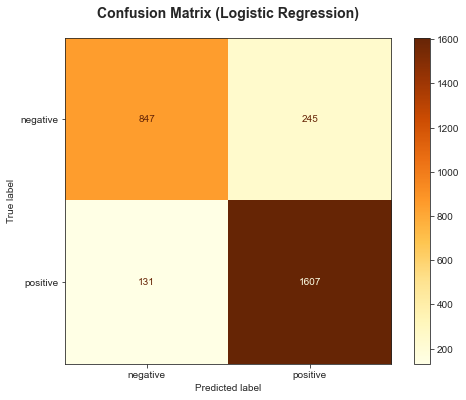

In [120]:
# Creating a confusion matrix data 
cm = confusion_matrix(f2_test, lr_predictions)

# Visualising both the models

fig, ax = plt.subplots(figsize=(8,6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels = ['negative', 'positive'])
disp.plot(cmap= 'YlOrBr', values_format = 'd', ax=ax)

plt.title('Confusion Matrix (Logistic Regression)', fontsize = 14, fontweight = 'bold', pad = 20)
plt.grid(False)
plt.show()

### Task 3:
In this task we are not just exploring if the buyer is happy or not, we are trying to predict if other customers will find the review usefful. And to build an acurate model we need a balanced distribution of classes. To ensure that we will use under-sampling.

In [114]:

from sklearn.utils import resample

# Separating the classes
df_helpful = df_review[df_review['is_helpful'] == 1]
df_not_helpful = df_review[df_review['is_helpful'] == 0]

# Downsmapling the 'Helpful' class to match the 'Not Helpful' class
df_helpful_ds = resample(df_helpful, replace = False, n_samples = len(df_not_helpful), random_state = 42)

# Merging back into a balanced dataframe
df_balanced = pd.concat([df_helpful_ds, df_not_helpful])

print(f"Balanced Dataset Distribution:\n{df_balanced['is_helpful'].value_counts()}")

Balanced Dataset Distribution:
1    268
0    268
Name: is_helpful, dtype: int64


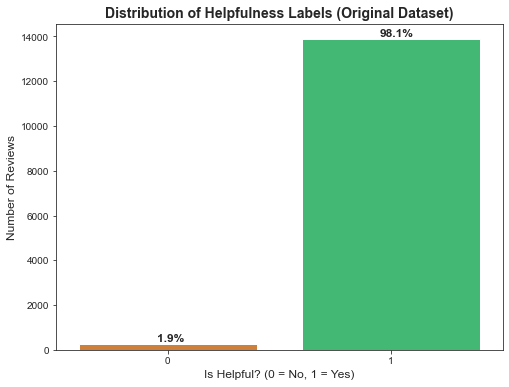

In [121]:
# Creating the plot for the original (imbalanced) distribution
plt.figure(figsize=(8, 6))
ax = sns.countplot(data=df_review, x='is_helpful', palette=['#e67e22', '#2ecc71'])

# Adding labels and title
plt.title('Distribution of Helpfulness Labels (Original Dataset)', fontsize=14, fontweight='bold')
plt.xlabel('Is Helpful? (0 = No, 1 = Yes)', fontsize=12)
plt.ylabel('Number of Reviews', fontsize=12)

# Adding percentage labels on top of the bars so the imbalance is obvious
total = len(df_review['is_helpful'])
for p in ax.patches:
    percentage = '{:.1f}%'.format(100 * p.get_height()/total)
    x = p.get_x() + p.get_width() / 2 - 0.05
    y = p.get_y() + p.get_height() + 100
    ax.annotate(percentage, (x, y), size = 12, fontweight='bold')

plt.show()

The plot above clearly shows that the original data is heavily imbalanced. To make it workable and train our models we had to create the balanced datset to make training of the models fair, so that we can get acurate output once the models are trained.

### Task 3b: 
### Creating Helpfulness Classifer

As we have both text(review_body) and numbers (rating) and that need to be merged to do so we will create a pipeline to keep the code organised.

#### Model 1: Logistic Regression

In [117]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Setting features and targets
h1 = df_balanced[['review_body', 'rating_num']]
h2 = df_balanced['is_helpful']\

# Spliting into Train and Test sets
h1_train, h1_test, h2_train, h2_test = train_test_split(
    h1, h2, test_size=0.2, random_state=42, stratify=h2
)

# Creating a ColumnTransformer to process text and numbers differently
# Text gets TF-IDF, Numbers will be as it is
preprocessor = ColumnTransformer(
    transformers=[
        ('text_vec', TfidfVectorizer(stop_words='english', max_features=1000), 'review_body'),
    ], remainder='passthrough') # 'passthrough' keeps the rating_num as a feature

# Creating and training the Pipeline
helpfulness_model = Pipeline([
    ('prep', preprocessor),
    ('clf', LogisticRegression())
])

helpfulness_model.fit(h1_train, h2_train)

# Predictions and Evaluation
h_preds = helpfulness_model.predict(h1_test)

print("--- Helpfulness Prediction Results (Balanced Data) ---")
print(classification_report(h2_test, h_preds))

--- Helpfulness Prediction Results (Balanced Data) ---
              precision    recall  f1-score   support

           0       0.81      0.96      0.88        54
           1       0.95      0.78      0.86        54

    accuracy                           0.87       108
   macro avg       0.88      0.87      0.87       108
weighted avg       0.88      0.87      0.87       108



 #### Model 2: Multinomial Navie Bayes

In [122]:
# Setting the Pipeline for Model 2 (Multinomial Naive Bayes) using text feature only
nb_help_pipeline = Pipeline([('text_vec', TfidfVectorizer(stop_words='english', max_features = 1000)),
                            ('clf', MultinomialNB())])

# Training using only the review text from balanced training set
nb_help_pipeline.fit(h1_train['review_body'], h2_train)

# Predictions and Evaluation
nb_h_preds = nb_help_pipeline.predict(h1_test['review_body'])

print("--- Model 2 (Multinomial Naive Bayes) Performance ---")
print(classification_report(h2_test, nb_h_preds))

--- Model 2 (Multinomial Naive Bayes) Performance ---
              precision    recall  f1-score   support

           0       0.88      0.69      0.77        54
           1       0.74      0.91      0.82        54

    accuracy                           0.80       108
   macro avg       0.81      0.80      0.79       108
weighted avg       0.81      0.80      0.79       108



### Task 3c:

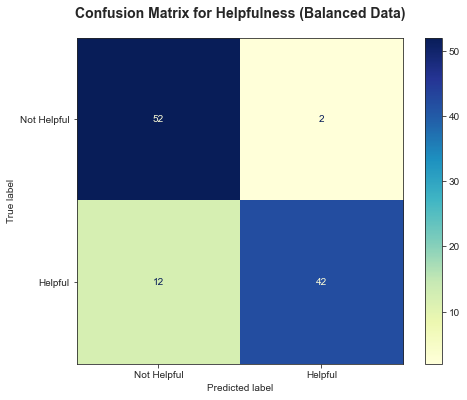

In [118]:
# Generating the confusion matrix data
cm_h = confusion_matrix(h2_test, h_preds)

# Plotting the graph
fig, ax = plt.subplots(figsize=(8, 6))
disp_h = ConfusionMatrixDisplay(confusion_matrix=cm_h, display_labels=['Not Helpful', 'Helpful'])

disp_h.plot(cmap='YlGnBu', values_format='d', ax=ax)

plt.title('Confusion Matrix for Helpfulness (Balanced Data)', fontsize=14, fontweight='bold', pad=20)
plt.grid(False)
plt.show()

The Logistic Regression Pipeline performed well by including the text vector and rating_num data. The model liveraged the correlation between the star rating and the helpfulness. However, on the other hand Navie Bayes model which relied only on text review was less effective in accessing the helpfulness of the review.

Sentiment classification was more "natural" for the models. Words like excellent or disappointed are strong indicators of sentiment. Helpfulness in Task 3 was more subjective and trick to grab by the models. 
The reliablity of the models were very low in accessing 'Helpfulness'which was extremely imbalanced on 98% positive and 2% negative. Without undersampling technique, the model would have achieved 98% accuracy simply by guessing "Helpful" every time, without actually learning anything.